# Rainfall as a triggering factor in a spatial domain

© 2024 Daniel F. Ruiz, Exneyder A. Montoya-Araque y Universidad EAFIT.

This notebook can be interactively run in [Google - Colab](https://colab.research.google.com/github/AppliedMechanics-EAFIT/EAFIT_slope_stability/blob/main/notebooks/02_trigg_factors/infinite_slope_rainfall_spatial.ipynb).

This notebook runs the model ``TRIGRS`` (Transient Rainfall Infiltration and Grid-Based Regional Slope-Stability Analysis), developed by {cite:t}`Baum_etal_2002_TRIGRSFortranProgram` and {cite:t}`Baum_etal_2008_TRIGRSFortranProgram`, and parallelized later by {cite:t}`Alvioli_Baum_2016_ParallelizationTRIGRSModel`

## Required modules and global setup for plots

In [1]:
import os
import subprocess
import textwrap
import itertools
# import requests

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
from IPython import get_ipython
import rasterio

if 'google.colab' in str(get_ipython()):
    print('Running on CoLab. Installing the required modules...')
    # subprocess.run('pip install ipympl', shell=True);
    # subprocess.run('pip install palettable', shell=True);
    subprocess.run('pip install pynewmarkdisp', shell=True);
    subprocess.run('pip install pysheds', shell=True);
    from google.colab import output, files
    output.enable_custom_widget_manager()
    
else:
    import tkinter as tk
    from tkinter.filedialog import askopenfilename

from pynewmarkdisp.spatial import get_hillshade
from pysheds.grid import Grid

# Figures setup
# %matplotlib widget
%matplotlib inline

mpl.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman", "cmr", "cmr10", "DejaVu Serif"],  # or 
    "mathtext.fontset": "cm",  # Use Computer Modern fonts for math
    "axes.formatter.use_mathtext": True,  # Use mathtext for axis labels
    "axes.unicode_minus": False,   # Use standard minus sign instead of a unicode character
})

## Creating directories

In [2]:
project_name = "ET_test"

# Create a folder called TRIGRS in the current working directory if it doesn't exist
workdir = os.getcwd()
exec_dir = os.path.join(workdir, project_name)
os.makedirs(f"{exec_dir}", exist_ok=True)  

# Create a folder inside TRIGRS to store the ascii files
inputs_dir = os.path.join(exec_dir, "inputs")
outputs_dir = os.path.join(exec_dir, "outputs")
os.makedirs(f"{inputs_dir}", exist_ok=True)
os.makedirs(f"{outputs_dir}", exist_ok=True)

## Functions

In [3]:
def tpx_in_maker(tpx_inputs):
    tpx_in_template = textwrap.dedent(
        f"""\
        TopoIndex 1.0.15; Name of project (up to 255 characters)
        TopoIndex analysis - Project: {tpx_inputs["proj_name"]}
        Flow-direction numbering scheme (ESRI=1, TopoIndex=2)
        {tpx_inputs["flow_dir_scheme"]}
        Exponent, Number of iterations
        {tpx_inputs["exponent_weight_fact"]}, {tpx_inputs["iterarions"]}
        Name of elevation grid file
        {project_name}/inputs/dem.asc
        Name of direction grid
        {project_name}/inputs/directions.asc
        Save listing of D8 downslope neighbor cells (TIdsneiList_XYZ)?  Enter T (.true.) or F (.false.)
        T
        Save grid of D8 downslope neighbor cells (***TIdscelGrid_XYZ)? Enter T (.true.) or F (.false.)
        T
        Save cell index number grid (TIcelindxGrid_XYZ)?  Enter T (.true.) or F (.false.)
        T
        Save list of cell number and corresponding index number (***TIcelindxList_XYZ)? Enter T (.true.) or F (.false.)
        T
        Save flow-direction grid remapped from ESRI to TopoIndex (TIflodirGrid_XYZ)? Enter T (.true.) or F (.false.)
        T
        Save grid of points on ridge crests (TIdsneiList_XYZ)? Enter T (.true.) or F (.false.); Sparse (T) or dense (F)?
        F,T
        ID code for output files? (8 characters or less)
        {tpx_inputs["proj_name"]}"""
    )
    with open("tpx_in.txt", "w") as file:
        file.write(tpx_in_template)
    return


def run_topoidx(tpx_inputs):
    tpx_in_maker(tpx_inputs)  # Generating initializing files
    subprocess.call([f"chmod +x ./{project_name}/Exe_TopoIndex"], shell=True)  # Change permission
    subprocess.call([f"./{project_name}/Exe_TopoIndex"])  # Running Fortran executable
    # Moving log file to outputs folder and renaming it
    os.rename(os.path.join(workdir, "TopoIndexLog.txt"), os.path.join(outputs_dir, f"TopoIndexLog_{tpx_inputs['proj_name']}.txt"))
    os.rename(os.path.join(workdir, "tpx_in.txt"), os.path.join(exec_dir, f"tpx_in_{tpx_inputs['proj_name']}.txt"))
    return


def tr_in_maker(trg_inputs):
    # Create text block for geotechnical parameters of each zone
    geoparams = ""
    for zone in trg_inputs["geoparams"].keys():
        z = trg_inputs["geoparams"][zone]
        txt_zone = "".join(
            [
                f"zone, {zone}\n",
                "cohesion, phi, uws, diffus, K-sat, Theta-sat, Theta-res, Alpha\n",
                f'{z["c"]}, {z["φ"]}, {z["γ_sat"]}, {z["D_sat"]}, {z["K_sat"]}, {z["θ_sat"]}, {z["θ_res"]}, {z["α"]}\n',
            ]
        )
        # print(txt_zone)
        geoparams = str().join([geoparams, txt_zone])
    # Update rifil entry with placeholder for each file
    trg_inputs["rifil"] = str().join(
        [f"{project_name}/inputs/ri{n}.asc\n" for n in range(1, len(trg_inputs["capt"]))]
    )

    # Template
    trg_in_template = (
        textwrap.dedent(
            f"""\
        Project: {trg_inputs['proj_name']}
        TRIGRS, version 2.1.00c, (meter-kilogram-second-degrees units)
        tx, nmax, mmax, zones
        {trg_inputs['tx']}, {trg_inputs['nmax']}, {trg_inputs['mmax']}, {trg_inputs['zones']}
        nzs, zmin, uww, nper t
        {trg_inputs['nzs']}, 0.001, 9.8e3, {trg_inputs['nper']}, {trg_inputs['t']}
        zmax, depth, rizero, Min_Slope_Angle (degrees), Max_Slope_Angle (degrees)
        {trg_inputs['zmax']}, {trg_inputs['depth']}, {trg_inputs['rizero']}, 0., 90.0
        """
        )
        + geoparams[:-1]
        + textwrap.dedent(
            f"""
        cri(1), cri(2), ..., cri(nper)
        {', '.join(map(str, trg_inputs['cri']))}
        capt(1), capt(2), ..., capt(n), capt(n+1)
        {', '.join(map(str, trg_inputs['capt']))}
        File name of slope angle grid (slofil)
        {project_name}/inputs/slope.asc
        File name of digital elevation grid (elevfil)
        {project_name}/inputs/dem.asc
        File name of property zone grid (zonfil)
        {project_name}/inputs/zones.asc
        File name of depth grid (zfil)
        {project_name}/inputs/zmax.asc
        File name of initial depth of water table grid   (depfil)
        {project_name}/inputs/depthwt.asc
        File name of initial infiltration rate grid   (rizerofil)
        {project_name}/inputs/rizero.asc
        List of file name(s) of rainfall intensity for each period, (rifil())
        """
        )
        + trg_inputs["rifil"][:-2]
        + textwrap.dedent(
            f"""
        File name of grid of D8 runoff receptor cell numbers (nxtfil)
        {project_name}/inputs/TIdscelGrid_{trg_inputs['proj_name']}.txt
        File name of list of defining runoff computation order (ndxfil)
        {project_name}/inputs/TIcelindxList_{trg_inputs['proj_name']}.txt
        File name of list of all runoff receptor cells  (dscfil)
        {project_name}/inputs/TIdscelList_{trg_inputs['proj_name']}.txt
        File name of list of runoff weighting factors  (wffil)
        {project_name}/inputs/TIwfactorList_{trg_inputs['proj_name']}.txt
        Folder where output grid files will be stored  (folder)
        {project_name}/outputs/
        Identification code to be added to names of output files (suffix)
        {trg_inputs['proj_name']}
        Save grid files of runoff? Enter T (.true.) or F (.false.)
        F
        Save grid of minimum factor of safety? Enter T (.true.) or F (.false.)
        T
        Save grid of depth of minimum factor of safety? Enter T (.true.) or F (.false.)
        T
        Save grid of pressure head at depth of minimum factor of safety? Enter T (.true.) or F (.false.)
        T
        Save grid of computed water table depth or elevation? Enter T (.true.) or F (.false.) followed by 'depth,' or 'eleva'
        T, depth
        Save grid files of actual infiltration rate? Enter T (.true.) or F (.false.)
        F
        Save grid files of unsaturated zone basal flux? Enter T (.true.) or F (.false.)
        F
        Save listing of pressure head and factor of safety ("flag")? (-9 sparse xmdv , -8 down-sampled xmdv, -7 full xmdv, -6 sparse ijz, -5 down-sampled ijz, -4 full ijz, -3 Z-P-Fs-saturation list -2 detailed Z-P-Fs, -1 Z-P-Fs list, 0 none). Enter flag value followed by down-sampling interval (integer).
        {trg_inputs['ψ_flag']}, {trg_inputs['nzs']}
        Number of times to save output grids and (or) ijz/xmdv files
        {trg_inputs['n_outputs']}
        Times of output grids and (or) ijz/xmdv files
        {', '.join(map(str, trg_inputs['t_n_outputs']))}
        Skip other timesteps? Enter T (.true.) or F (.false.)
        F
        Use analytic solution for fillable porosity?  Enter T (.true.) or F (.false.)
        T
        Estimate positive pressure head in rising water table zone (i.e. in lower part of unsat zone)?  Enter T (.true.) or F (.false.)
        T
        Use psi0=-1/alpha? Enter T (.true.) or F (.false.) (False selects the default value, psi0=0)
        F
        Log mass balance results?   Enter T (.true.) or F (.false.)
        T
        Flow direction (Enter "gener", "slope", or "hydro")
        {trg_inputs['flowdir']}
        Add steady background flux to transient infiltration rate to prevent drying beyond the initial conditions during periods of zero infiltration?
        T
        Specify file extension for output grids. Enter T (.true.) for ".asc" or F for ".txt"
        T
        Ignore negative pressure head in computing factor of safety (saturated infiltration only)?   Enter T (.true.) or F (.false.)
        T
        Ignore height of capillary fringe in computing pressure head for unsaturated infiltration option?   Enter T (.true.) or F (.false.)
        T
        Parameters for deep pore-pressure estimate in SCOOPS ijz output: Depth below ground surface (positive, use negative value to cancel this option), pressure option (enter 'zero' , 'flow' , 'hydr' , or 'relh')
        -50.0,flow
        """
        )
    )
    # Create txt file
    with open("tr_in.txt", "w") as file:
        file.write(trg_in_template)
    return


def run_trigrs(trg_inputs):
    # Correcting sign for `Alpha` parameters for saturated/unsaturated models
    for z in trg_inputs["geoparams"].keys():
        zone = trg_inputs["geoparams"][z]
        if "S" in trg_inputs["model"]:
            zone["α"] = -1 * abs(zone["α"])
        else:
            zone["α"] = abs(zone["α"])

    # Correcting sign for `mmax` parameters for finite/infinite models
    if "I" in trg_inputs["model"]:
        trg_inputs["mmax"] = -1 * abs(trg_inputs["mmax"])
    else:
        trg_inputs["mmax"] = abs(trg_inputs["mmax"])

    # Generating initializing file and running TRIGRS executable
    tr_in_maker(trg_inputs)  # Initializing files from template
    if trg_inputs["parallel"]:
        exe = f"./{project_name}/Exe_TRIGRS_par"
        subprocess.call([f"chmod +x {exe}"], shell=True)  # Change permission
        subprocess.call(
            [f'mpirun -np {trg_inputs["NP"]} {exe}'], shell=True
        )  # Running TRIGRS executable
    else:
        exe = f"./{project_name}/Exe_TRIGRS_ser"
        subprocess.call([f"chmod +x {exe}"], shell=True)  # Change permission
        subprocess.call([exe], shell=True)  # Running TRIGRS executable
    return


def get_param(zone, param):
    return trg_inputs['geoparams'][zone.iloc[0]][param]

def get_df(file):
    γ_w = 9.8e3  # [N/m3] unit weight of water
    # Reading file
    df = pd.read_csv(file,
                     names=['i_tr', 'j_tr', 'elev', 'ψ', 'θ'],
                     skiprows=7, sep='\s+')#delim_whitespace=True)
    # Correcting indices to match numpy notation
    df['i'] = df['j_tr'].max() - df['j_tr']
    df['j'] = df['i_tr'] - 1
    df.drop(columns=['i_tr', 'j_tr'], inplace=True)
    # Calculating depths from elevations
    elev_max = df.groupby(['i', 'j'])['elev'].transform('max')
    df['z'] = elev_max - df['elev'] + 0.001
    df = df[['i', 'j', 'elev', 'z', 'ψ', 'θ']]
    # Assigning zones and geotechnical parameters
    df['zone'] = zones[df['i'], df['j']]
    for param_name in trg_inputs['geoparams'][1].keys():
        df[param_name] = df.groupby('zone')['zone'].transform(
            get_param, param=param_name)
    # Correting rows with ψ==0 (watertable) due to numerical errors
    mask = (df['ψ'] == 0) & (df['z'] > 0.001) & (df['θ'] == df['θ_sat'])
    # df.loc[mask, 'z'] = df.loc[mask, 'z'] + 1/df.loc[mask, 'α']
    # df.loc[mask, 'elev'] = df.loc[mask, 'elev'] - 1/df.loc[mask, 'α']
    # df.sort_values(['i', 'j', 'z'], inplace=True)
    df.drop(df[mask].index, inplace=True)  # This eliminates the wt rows
    # Assigning slope
    df['δ'] = slope[df['i'], df['j']]
    δrad = np.deg2rad(df['δ'])
    # Calculating effective stress parameter, χ
    df['χ'] = (df['θ'] - df['θ_res']) / (df['θ_sat'] - df['θ_res'])
    # Specific gravity
    df['Gs'] = (df['γ_sat']/γ_w - df['θ_sat']) / (1 - df['θ_sat'])
    # unit weight at unsat and sat zones
    df['γ_nat'] = (df['Gs'] * (1 - df['θ_sat']) + df['θ']) * γ_w
    # average unit weight
    γ_cumul = df.groupby(['i', 'j'])['γ_nat'].transform('cumsum')
    idx = df.groupby(['i', 'j'])['γ_nat'].cumcount() + 1
    df['γ_avg'] = γ_cumul / idx
    # Factor of safety
    fs1 = np.tan(np.deg2rad(df['φ'])) / np.tan(δrad)
    fs2_num = df['c'] - df['ψ'] * γ_w * df['χ'] * np.tan(np.deg2rad(df['φ']))
    fs2_den = df['γ_avg'] * df['z'] * np.sin(δrad) * np.cos(δrad)
    fs = fs1 + fs2_num/fs2_den
    fs[fs > 3] = 3
    df['fs'] = fs
    return df

<>:203: SyntaxWarning: invalid escape sequence '\s'
<>:203: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_3691/527938573.py:203: SyntaxWarning: invalid escape sequence '\s'
  skiprows=7, sep='\s+')#delim_whitespace=True)


In [4]:
def load_ascii_raster(path, dtype=None):
    raster = np.loadtxt(path, skiprows=6)
    header = np.loadtxt(path, max_rows=6, dtype=object)
    header = {
        "ncols": int(header[0, 1]),
        "nrows": int(header[1, 1]),
        "xllcorner": float(header[2, 1]),
        "yllcorner": float(header[3, 1]),
        "cellsize": float(header[4, 1]),
        "nodata_value": eval(header[5, 1]),
    }
    raster[np.where(raster == header["nodata_value"])] = np.nan
    raster = raster.astype(dtype) if dtype is not None else raster
    return (raster, header)


def get_asc_from_url(file_name):
    base_url = "https://raw.githubusercontent.com/eamontoyaa/data4testing/main/trigrs/tutorial_data"
    url = f"{base_url}/{file_name}.asc"
    output_path = os.path.join(inputs_dir, f"{file_name}.asc")

    # if os.path.exists(output_path):
    #     print(f"🟡 {file_name}.asc already exists at {output_path} — skipping download.")
    #     return

    try:
        subprocess.run(["wget", "-q", "-O", output_path, url], check=True)
        print(f"✅ {file_name}.asc downloaded successfully.")
    except subprocess.CalledProcessError:
        print(f"❌ Failed to download {file_name}.asc from {url}")

def load_raster(file_path, masked=True):
    """
    Load a raster file (e.g., DEM or other geospatial raster) and extract its key metadata.

    Parameters:
        file_path (str): Path to the raster file (e.g., a GeoTIFF).

    Returns:
        tuple:
            - data (np.ndarray): 2D array of raster values (first band).
            - transform (Affine): Affine transformation mapping pixel coordinates to spatial coordinates.
            - bounds (BoundingBox): Bounding box of the raster in spatial coordinates.
            - crs (CRS): Coordinate Reference System of the raster.
            - nodata (float or int or None): Value used to represent no-data pixels, if defined.
    """
    with rasterio.open(file_path) as src:
        data = src.read(1, masked=masked)  # Read the first band, optionally masked
        transform = src.transform
        bounds = src.bounds
        crs = src.crs
        nodata = src.nodata
        # affine = src.affine
    return data, transform, bounds, crs, nodata


def save_raster(file_path, array, crs, transform, nodata=None, format="tif"):
    """
    Save a NumPy array as a GeoTIFF using rasterio.

    Parameters:
        file_path (str): Path to the raster file (e.g., a GeoTIFF)..
        array (np.ndarray): 2D array to be saved.
        crs (str or CRS): Coordinate reference system.
        transform (Affine): Affine transform for the raster.
    """
    driver = "GTiff" if format == "tif" else "AAIGrid"

    with rasterio.open(
        file_path,
        "w",
        driver=driver,
        height=array.shape[0],
        width=array.shape[1],
        count=1,
        dtype=array.dtype,
        crs=crs,
        transform=transform,
        nodata=nodata,
    ) as dst:
        dst.write(array, 1)


## Loading executables and input files

In [5]:
def download_file_from_github(file, url_path, output_path, make_executable=False):
    os.makedirs(output_path, exist_ok=True)
    destination = os.path.join(output_path, file)

    # ✅ Check if file already exists
    if os.path.exists(destination):
        print(f"🟡 File already exists at: {destination} — skipping download.")
        return

    url = f"{url_path.rstrip('/')}/{file}"

    try:
        print(f"⬇️ Downloading from: {url}")
        subprocess.run(["wget", "-q", "-O", destination, url], check=True)

        if make_executable:
            os.chmod(destination, 0o755)
            print(f"🔧 File marked as executable.")

        print(f"✅ File downloaded to: {destination}")
    except subprocess.CalledProcessError as e:
        print(f"❌ Download failed: {e}")


url_path = "https://raw.githubusercontent.com/eamontoyaa/data4testing/main/trigrs/"  # URL of the raw file on GitHub
output_path = "./{project_name}/"  # Path where you want to save the downloaded file

### TopoIndex

In [6]:
file = "Exe_TopoIndex"  # Name of the file to download
download_file_from_github(file, url_path, os.path.join(os.getcwd(), project_name))

⬇️ Downloading from: https://raw.githubusercontent.com/eamontoyaa/data4testing/main/trigrs/Exe_TopoIndex
✅ File downloaded to: /mnt/d/OneDrive - Universidad EIA/EAMA/Dev/GitHub/EAFIT_slope_stability/notebooks/02_trigg_factors/ET_test/Exe_TopoIndex


### TRIGRS

In [7]:
file = "Exe_TRIGRS_ser"  # Name of the file to download
download_file_from_github(file, url_path, os.path.join(os.getcwd(), project_name))

⬇️ Downloading from: https://raw.githubusercontent.com/eamontoyaa/data4testing/main/trigrs/Exe_TRIGRS_ser
✅ File downloaded to: /mnt/d/OneDrive - Universidad EIA/EAMA/Dev/GitHub/EAFIT_slope_stability/notebooks/02_trigg_factors/ET_test/Exe_TRIGRS_ser


In [8]:
# Check the files in the executables folder
os.listdir(exec_dir)

['Exe_TopoIndex', 'Exe_TRIGRS_ser', 'inputs', 'outputs']

## Running the TRIGRS model in a spatial domain

### General inputs

In [9]:
model = "UF"  # Choose among UF, UI, SF, SI → | U: unsaturated | S: saturated | F: finite | I: infinite |

rainfall_mm_h = [1.08, 324.0]  # [mm/h] Rainfal intensities for each period.
duration_h = [0, 48, 60]  # [h] Rainfall duration for each period. Always starts at 0 and contains n+1 elements, where n is the number of rainfall intensity periods

output_times_h = [0.0, 12.0, 24.0, 28.0, 51.0, 60.0] # [h] Six output times between 0 and max(duration_h)


In [10]:
# rainfall_mm_h = [50]  # [mm/h] Rainfal intensities for each period.
# duration_h = [0, 2]  # [h] Rainfall duration for each period. Always starts at 0 and contains n+1 elements, where n is the number of rainfall intensity periods
# output_times_h = [0.0, 12.0, 24.0, 28.0, 51.0, 60.0] # [h] Six output times between 0 and max(duration_h)
# # 100 mm en total (2 h)

In [11]:
# rainfall_mm_h = [20, 10]  # [mm/h] Rainfal intensities for each period.
# duration_h = [0, 3, 7]  # [h] Rainfall duration for each period. Always starts at 0 and contains n+1 elements, where n is the number of rainfall intensity periods
# output_times_h = [0.0, 12.0, 24.0, 28.0, 51.0, 60.0] # [h] Six output times between 0 and max(duration_h)

# # 20 mm/h en 3 h > 60 mm
# # 10 mm/h en 4 h > 40 mm


### Units conversion

In [12]:
# Do not edit this cell!
rainfall_int =  np.array(rainfall_mm_h) / 36e5  # [mm/h] to [m/s]
cumul_duration = np.array(duration_h) * 3600  # [h] to [s]
output_times = np.array(output_times_h) * 3600  # [h] to [s]

In [13]:
rainfall_int

array([3.e-07, 9.e-05])

### Creating `.asc` files

In [14]:
testing_data = True

if testing_data is False:
    # Read raw DEM
    dem, transform_dem, bounds_dem, crs_dem, nodata_dem = load_raster(os.path.join(inputs_dir, f"dem.tif"), masked=True)
    grid = Grid.from_raster(os.path.join(inputs_dir, f"dem.tif"))
    dem = grid.read_raster(os.path.join(inputs_dir, f"dem.tif"))

    # Fill depressions
    flooded_dem = grid.fill_depressions(dem)

    # Resolve flats
    inflated_dem = grid.resolve_flats(flooded_dem)

    # Specify directional mapping
    #N    NE    E    SE    S    SW    W    NW
    dirmap = (64, 128, 1, 2, 4, 8, 16, 32)  # ESRI flow direction scheme
    dirmap = (2, 3, 6, 9, 8, 7, 4, 1)  # TopoIndex flow direction scheme
    # Compute flow directions
    # -------------------------------------
    fdir = grid.flowdir(inflated_dem, dirmap=dirmap)
    fdir[fdir <= 0] = -9999
    fdir[dem==nodata_dem] = -9999
    # Save flow directions as ASCII file
    save_raster(f"{inputs_dir}/directions.tif", fdir, crs=crs_dem, transform=transform_dem, nodata=-9999, format="tif")

**Note:**

If you are loading locally your own spatial input data, rerun the notebook from this point.

In [15]:
# for file in ['dem', 'zmax', 'depthwt', 'slope', 'directions', 'rizero', 'zones']:
#     get_asc_from_url(file)
if testing_data:
    for file in ['dem', 'zmax', 'depthwt', 'slope', 'directions', 'rizero', 'zones']:
        get_asc_from_url(file)
    dem, header = load_ascii_raster(f"{inputs_dir}/dem.asc")
    cellsize = header['cellsize']
    slope, header = load_ascii_raster(f"{inputs_dir}/slope.asc")
    directions, header = load_ascii_raster(f"{inputs_dir}/directions.asc")
    zones, header = load_ascii_raster(f"{inputs_dir}/zones.asc")
    depth, header = load_ascii_raster(f"{inputs_dir}/zmax.asc")
    rizero, header = load_ascii_raster(f"{inputs_dir}/rizero.asc")
    depth_w, header = load_ascii_raster(f"{inputs_dir}/depthwt.asc")
    
if not testing_data:
    dem, transform_dem, bounds_dem, crs_dem, nodata_dem = load_raster(os.path.join(inputs_dir, f"dem.tif"), masked=True)
    cellsize = transform_dem.a
    slope, transform_slope, bounds_slope, crs_slope, nodata_slope = load_raster(os.path.join(inputs_dir, "slope.tif"), masked=True)
    directions, transform_directions, bounds_directions, crs_directions, nodata_directions = load_raster(os.path.join(inputs_dir, "directions.tif"), masked=True)
    zones, transform_zones, bounds_zones, crs_zones, nodata_zones = load_raster(os.path.join(inputs_dir, "zones.tif"), masked=True)
    depth, transform_depth, bounds_depth, crs_depth, nodata_depth = load_raster(os.path.join(inputs_dir, "zmax.tif"), masked=True)
    depth_w, transform_depth_w, bounds_depth_w, crs_depth_w, nodata_depth_w = load_raster(os.path.join(inputs_dir, "depthwt.tif"), masked=True)

    nodata_mask = (dem == nodata_dem) | (slope == nodata_slope) | (directions == nodata_directions) | \
    (zones == nodata_zones) | (depth == nodata_depth) | (depth_w == nodata_depth_w)

    # Convert rasters to the appropriate data types and apply nodata mask
    for raster, file_name in zip([dem, slope, directions, zones, depth, depth_w], ['dem', 'slope', 'directions', 'zones', 'zmax', 'depthwt']):
        if file_name in ['zones', 'directions']:   
            raster = raster.astype(np.int32)
        else:  # raster to float32
            raster = raster.astype(np.float32)
        # apply nodata mask
        raster[nodata_mask] = -9999
        # save raster
        save_raster(f"{inputs_dir}/{file_name}.asc", raster, crs_dem, transform_dem, nodata=-9999, format="AAIGrid")

✅ dem.asc downloaded successfully.
✅ zmax.asc downloaded successfully.
✅ depthwt.asc downloaded successfully.
✅ slope.asc downloaded successfully.
✅ directions.asc downloaded successfully.
✅ rizero.asc downloaded successfully.
✅ zones.asc downloaded successfully.


### Visualizing spatial inputs (conditioning factors)

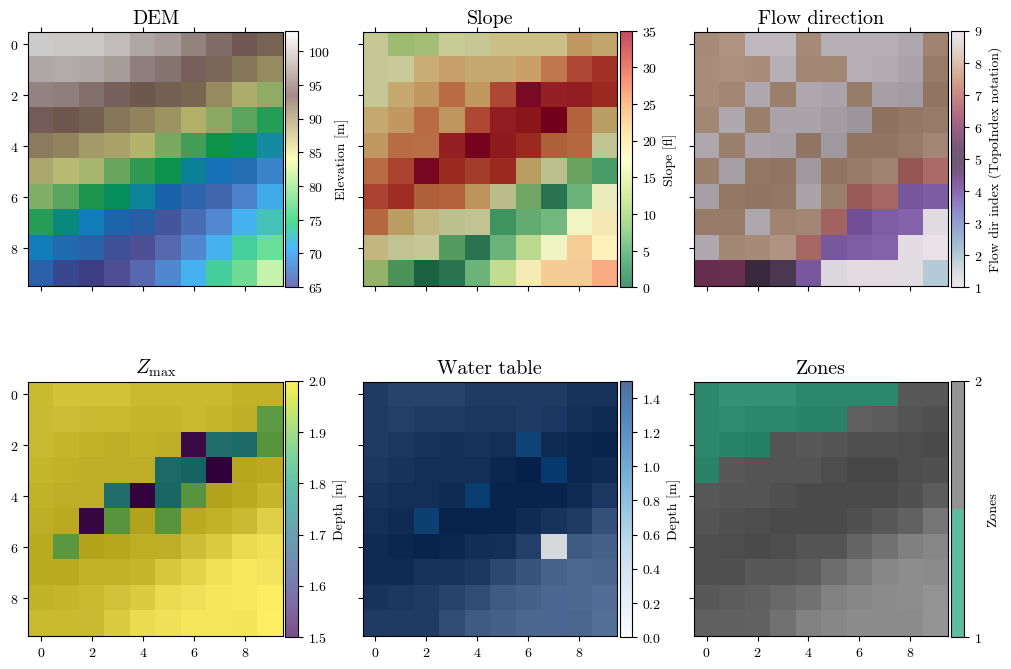

In [16]:
hsd = get_hillshade(dem, sun_azimuth=000, sun_altitude=30, cellsize=cellsize)

fig, axs = plt.subplots(nrows=2, ncols=3, layout='constrained', figsize=(10, 7), sharex=True, sharey=True)
(ax0, ax1, ax2, ax3, ax4, ax5) = axs.flatten()

for ax in [ax0, ax1, ax2, ax3, ax4, ax5]:
    im_hsd = ax.matshow(hsd, cmap="gray", interpolation="none")

# DEM
im_dem = ax0.matshow(dem, cmap="terrain", alpha=0.7, interpolation="none")
ax0.set_title("DEM", fontsize='x-large')
fig.colorbar(im_dem, ax=ax0, orientation='vertical', shrink=0.75, pad=0.01, label='Elevation [m]')
# Slope
im_slope = ax1.matshow(slope, cmap="RdYlGn_r", alpha=0.7, interpolation="none")
ax1.set_title("Slope", fontsize='x-large')
fig.colorbar(im_slope, ax=ax1, orientation='vertical', shrink=0.75, pad=0.01, label='Slope [°]')
# Directions
im_dirflow = ax2.matshow(directions, cmap="twilight", alpha=0.7, interpolation="none")
ax2.set_title("Flow direction", fontsize='x-large')
fig.colorbar(im_dirflow, ax=ax2, orientation='vertical', shrink=0.75, pad=0.01, label='Flow dir index (TopoIndex notation)')
# Zmax
im_zmax = ax3.matshow(depth, cmap='viridis', alpha=0.7, interpolation="none")
ax3.set_title("$Z_\\mathrm{max}$", fontsize='x-large')
fig.colorbar(im_zmax, ax=ax3, orientation='vertical', shrink=0.75, pad=0.01, label='Depth [m]')
# Water table depth
im_depth = ax4.matshow(depth_w, cmap='Blues', alpha=0.7, interpolation="none")
ax4.set_title("Water table", fontsize='x-large')
fig.colorbar(im_depth, ax=ax4, orientation='vertical', shrink=0.75, pad=0.01, label='Depth [m]')
# Zones
im_zones = ax5.matshow(zones, cmap=plt.colormaps.get_cmap("Dark2").resampled(len(np.unique(zones))),
                       alpha=0.7, interpolation="none")
ax5.set_title("Zones", fontsize='x-large')
fig.colorbar(im_zones, ax=ax5, orientation='vertical', shrink=0.75, pad=0.01, label='Zones', ticks=np.unique(zones))


for ax in [ax0, ax3]:
    ax.yaxis.set_ticks_position('left')
for ax in [ax3, ax4, ax5]:
    ax.xaxis.set_ticks_position('bottom')

fig.canvas.header_visible = False
fig.canvas.toolbar_position = 'bottom'
plt.show()

In [20]:
# n zones as non nan unique values in zones raster
n_zones = len(np.unique(zones[~np.isnan(zones)]))
print(f"Number of zones: {n_zones}")

Number of zones: 2


In [18]:
# Running TopoIndex
tpx_inputs = {
    "flow_dir_scheme": 2,  # 1 for ESRI, 2 for TopoIndex
    "exponent_weight_fact": 25,
    "iterarions": 10,
    "proj_name": project_name[:8],
}
run_topoidx(tpx_inputs)

   TopoIndex: Topographic Indexing and
  flow distribution factors for routing
  runoff through Digital Elevation Models
             By Rex L. Baum
        U.S. Geological Survey
      Version 1.0.14, 11May2015
 -----------------------------------------
 
 TopoIndex analysis - Project: ET_test
         100  = number of data cells
         100  = total number of cells
 Reading elevation grid data
 Initial elevation indexing completed
 Finding D8 neighbor cells
 nxtcel() nodata (integer,floating)=        -9999  -9999.00000    
 Identifying downslope cells and grid mismatches
 No grid mismatch found!
 Correcting cell index numbers
 Computing weighting factors
 Saving results to disk


### TRIGRS inputs

Do not edit those parameters with the → 🛇 ← symbol.

In [21]:
trg_inputs = {
    "proj_name": project_name[:8],  # Name of the project → 🛇 ←
    "model": model,  # S-saturated or U-unsaturated + F-finite or I-infinite → 🛇 ←
    "tx": 20, # [] tx*nper determines how many time steps are used in the computations → 🛇 ←
    "nmax": 30,  # [] Ma number of roots 𝚲n and terms in series solutions for UNS.zone → 🛇 ←
    "mmax": 100,  # [] Max number of terms in series solution for FIN depth. If <0: INF depth → 🛇 ←
    "zones": n_zones,  # [] Number of zones
    "nzs": 20,  # [] Vertical increments until zmax → 🛇 ←
    "nper": len(rainfall_int),  # [-] Periods of rainfall (N) → 🛇 ←
    "t": cumul_duration[-1],  # [s] Elapsed time since the start of the storm (t) → 🛇 ←
    "zmax": -3.001,  # [m] Max. depth to compute Fs and Ψ (if <0 read from grid file) → 🛇 ←
    "depth": -2.4,  # [m] Water table depth (d) (if <0 read from grid file) → 🛇 ←
    "rizero": 1e-9,  # [m/s] Steady pre-storm and long-term infilt. (Izlt) (if <0 read from grid file)
    "geoparams":{
        1: {
            "c": 3.5e3,  # [Pa] soil cohesion for effective stress (c')
            "φ": 35,  # [deg] soil friction angle for effective stress (φ')
            "γ_sat": 22.0e3,  # [N/m3]  unit weight of soil (γs)
            "D_sat": 6.0e-6,  # [m2/s] Saturated hydraulic diffusivity (D0)
            "K_sat": 1.0e-7,  # [m/s] Saturated hydraulic conductivity (Ks)
            "θ_sat": 0.45,  # [-] Saturated water content (θs)
            "θ_res": 0.05,  # [-] Residual water content (θr)
            "α": 0.5,  # [1/m] Fitting parameter. If <0: saturated infiltration
        },
        2: {
            "c": 8e3,  # [Pa] soil cohesion for effective stress (c')
            "φ": 31,  # [deg] soil friction angle for effective stress (φ')
            "γ_sat": 22.0e3,  # [N/m3]  unit weight of soil (γs)
            "D_sat": 8.0e-4,  # [m2/s] Saturated hydraulic diffusivity (D0)
            "K_sat": 1.0e-4,  # [m/s] Saturated hydraulic conductivity (Ks)
            "θ_sat": 0.45,  # [-] Saturated water content (θs)
            "θ_res": 0.06,  # [-] Residual water content (θr)
            "α": 8,  # [1/m] Fitting parameter. If <0: saturated infiltration
        },
        # 3: {
        #     "c": 3.5e3,  # [Pa] soil cohesion for effective stress (c')
        #     "φ": 35,  # [deg] soil friction angle for effective stress (φ')
        #     "γ_sat": 22.0e3,  # [N/m3]  unit weight of soil (γs)
        #     "D_sat": 6.0e-6,  # [m2/s] Saturated hydraulic diffusivity (D0)
        #     "K_sat": 1.0e-7,  # [m/s] Saturated hydraulic conductivity (Ks)
        #     "θ_sat": 0.45,  # [-] Saturated water content (θs)
        #     "θ_res": 0.05,  # [-] Residual water content (θr)
        #     "α": 0.5,  # [1/m] Fitting parameter. If <0: saturated infiltration
        # },
        # 4: {
        #     "c": 8e3,  # [Pa] soil cohesion for effective stress (c')
        #     "φ": 31,  # [deg] soil friction angle for effective stress (φ')
        #     "γ_sat": 22.0e3,  # [N/m3]  unit weight of soil (γs)
        #     "D_sat": 8.0e-4,  # [m2/s] Saturated hydraulic diffusivity (D0)
        #     "K_sat": 1.0e-4,  # [m/s] Saturated hydraulic conductivity (Ks)
        #     "θ_sat": 0.45,  # [-] Saturated water content (θs)
        #     "θ_res": 0.06,  # [-] Residual water content (θr)
        #     "α": 8,  # [1/m] Fitting parameter. If <0: saturated infiltration
        # }
    },
    "cri": tuple(rainfall_int),  # [m/s] Rainfall intensities  (Inz) → 🛇 ←
    "capt": tuple(cumul_duration),  # [s] Cumulative duration of rainfall cri[i] → 🛇 ←
    "flowdir": "gener",  # Method for maximum allowed Ψ ("gener", "slope", or "hydro")) → 🛇 ←
    "n_outputs": len(output_times),  # [-] No of raster outputs at different t → 🛇 ←
    "t_n_outputs": tuple(output_times),#t,  # [s] Time at which to save raster files → 🛇 ←
    "ψ_flag": -4, # → 🛇 ←
    "parallel": False,  # [-] Run in parallel → 🛇 ←
    "NP" : 4, # Number of processors → 🛇 ←
    # "inz_n_outputs": inz_n_outputs #inz,  # [s] Rainfall intensities at which to save raster files
}

run_trigrs(trg_inputs)

 
 TRIGRS: Transient Rainfall Infiltration
 and Grid-based Regional Slope-Stability
                Analysis
        Version 2.1.00c, 02 Feb 2022
   By Rex L. Baum and William Z. Savage
        U.S. Geological Survey
 -----------------------------------------
 
 Opening default initialization file
 TRIGRS, version 2.1.00c, (meter-kilogram-second-degrees units)                                                                                                                                                                                                 
 Unsaturated infiltration model selected for cells in zone           1 .
 Unsaturated infiltration model selected for cells in zone           2 .
 ******** Zone            1  *********
 Using saturated infiltration model to avoid
 early-time errors in unsaturated infiltration model.
 ******** Zone            2  *********
 Using unsaturated infiltration model.
 ********  ********  ********  *********
 ET_test/inputs/TIgrid_size.txt T
 Readin

Note: The following floating-point exceptions are signalling: IEEE_UNDERFLOW_FLAG IEEE_DENORMAL
STOP 0


### Visualizing spatial outputs of *FS*

In [22]:
def read_time(file):
    with open(file, 'r') as file:
        lines = file.readlines()
        time = float(lines[4].split()[-1])
    return time

actual_output_times = []
for i in range(1, trg_inputs["n_outputs"]+1):
    time = read_time(f'{outputs_dir}/TR_ijz_p_th_{project_name[:8]}_{i}.txt')
    actual_output_times.append(time)

actual_output_times, list(output_times)

([0.0, 43200.0, 86400.0, 97200.0, 183600.0, 216000.0],
 [np.float64(0.0),
  np.float64(43200.0),
  np.float64(86400.0),
  np.float64(100800.0),
  np.float64(183600.0),
  np.float64(216000.0)])

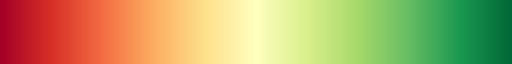

In [23]:
norm = mpl.colors.Normalize(vmin=.5, vmax=2)  # Modify vmin and vmax based on your data range
cmap = mpl.cm.RdYlGn
cmap.set_under('xkcd:reddish brown')  # Set color for values below vmin
cmap

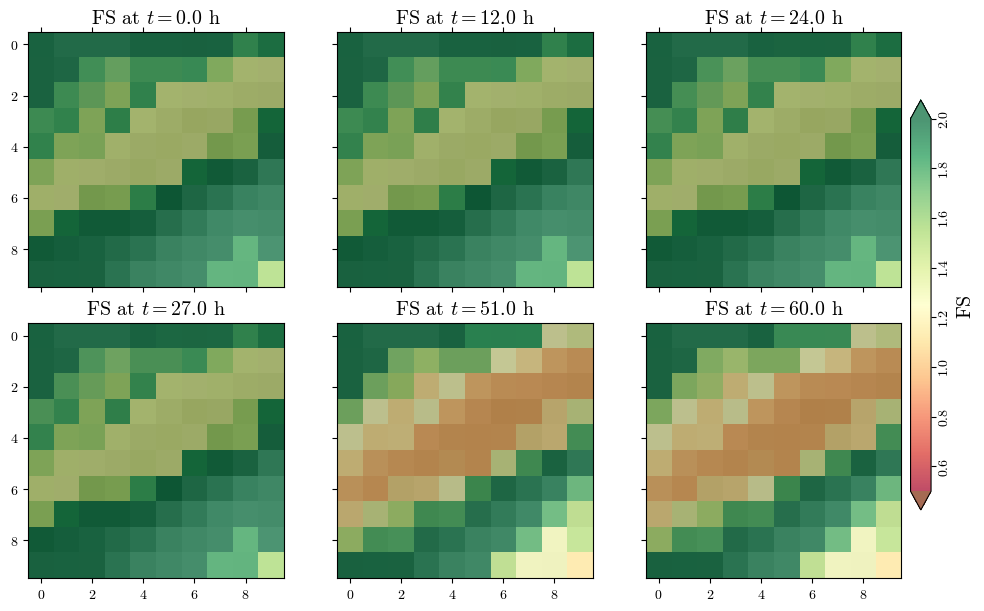

In [24]:
n_subplots = len(actual_output_times)
nrows=np.ceil(n_subplots/3).astype(int)

fig, axs = plt.subplots(ncols=3, nrows=nrows, figsize=(10, 3*nrows), layout='constrained', sharex=True, sharey=True)
all_fs = []
for i, t in enumerate(actual_output_times):
    fs_output_file = f"{outputs_dir}/TRfs_min_{project_name[:8]}_{i+1}.asc"
    fs, header = load_ascii_raster(fs_output_file)
    all_fs.append(fs)
    ax = axs[i//3, i%3]
    im_hsd = ax.matshow(hsd, cmap="gray", interpolation="none")    
    im_fs = ax.matshow(fs, cmap=cmap, alpha=0.7, norm=norm)

    ax.set_title(f"FS at $t={t/3600:.1f}$ h", fontsize='x-large')

for ax in axs.flatten():
    # ax.images[1].set_clim(vmin=min_fs, vmax=max_fs)
    ax.xaxis.set_ticks_position('bottom') if ax.get_subplotspec().is_last_row() else None

cbar = fig.colorbar(im_fs, ax=axs, orientation='vertical', shrink=0.75, pad=0.01, extend='both')
cbar.ax.tick_params(axis="y", labelrotation=90, pad=1.5)
cbar.set_label('FS', rotation=90, size="x-large")
[label.set_va("center") for label in cbar.ax.get_yticklabels()]
fig.canvas.header_visible = False
fig.canvas.toolbar_position = 'bottom'
plt.show()

### Visualizing spatial outputs of $\psi$

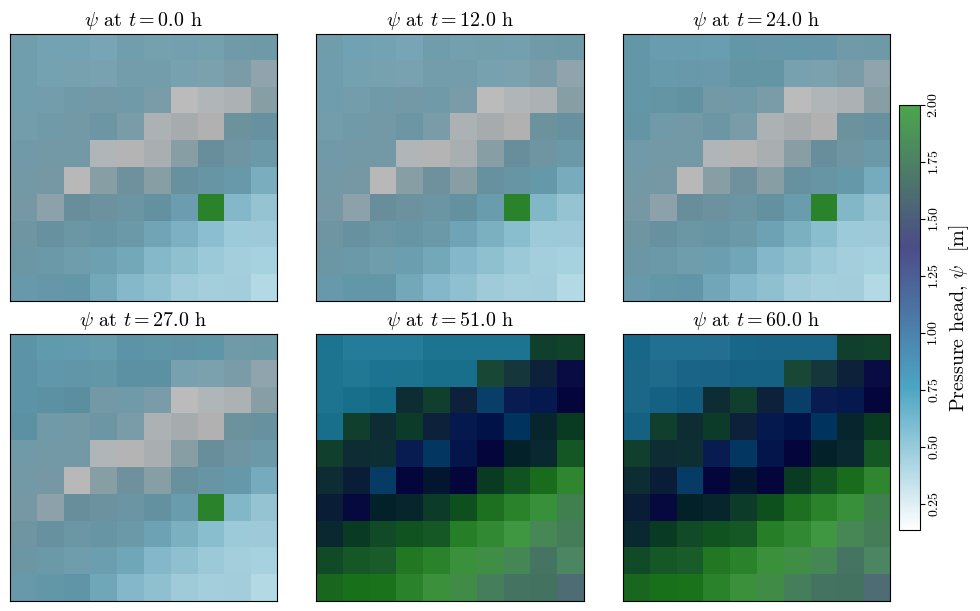

In [25]:
n_subplots = len(actual_output_times)
nrows=np.ceil(n_subplots/3).astype(int)

fig, axs = plt.subplots(ncols=3, nrows=nrows, figsize=(10, 3*nrows), layout='constrained', sharex=True, sharey=True)
all_psi = []
for i, t in enumerate(actual_output_times):
    psi_output_file = f"{outputs_dir}/TRp_at_fs_min_{project_name[:8]}_{i+1}.asc"
    psi, header = load_ascii_raster(psi_output_file)
    all_psi.append(psi)
    ax = axs[i//3, i%3]
    im_hsd = ax.matshow(hsd, cmap="gray", interpolation="none")
    im_psi = ax.matshow(psi, cmap='ocean_r', alpha=0.7, interpolation="none")#, vmin=0, vmax=np.nanmax(depth))

    ax.set_title(f"$\\psi$ at $t={t/3600:.1f}$ h", fontsize='x-large')
    ax.set_xticks([])
    ax.set_yticks([])

min_psi, max_psi = np.nanmin(all_psi), np.nanmax(all_psi)  # change vmin and vmax to each subplot
for ax in axs.flatten():
    ax.images[1].set_clim(vmin=min_psi, vmax=max_psi)
    ax.xaxis.set_ticks_position('bottom') if ax.get_subplotspec().is_last_row() else None

cbar = fig.colorbar(im_psi, ax=axs, orientation='vertical', shrink=0.75, pad=0.01)
cbar.ax.tick_params(axis="y", labelrotation=90, pad=1.5)
cbar.set_label('Pressure head, $\\psi$  [m]', rotation=90, size="x-large")
[label.set_va("center") for label in cbar.ax.get_yticklabels()]
fig.canvas.header_visible = False
fig.canvas.toolbar_position = 'bottom'
plt.show()

## Output to dataframe

In [26]:
def get_param(zone, param):
    return trg_inputs['geoparams'][zone.iloc[0]][param]

def get_df(file):
    γ_w = 9.8e3  # [N/m3] unit weight of water
    # Reading file
    df = pd.read_csv(file, names=['i_tr', 'j_tr', 'elev', 'ψ', 'θ'], skiprows=7, sep='\s+')
    # Correcting indices to match numpy notation
    df['i'] = df['j_tr'].max() - df['j_tr']
    df['j'] = df['i_tr'] - 1
    df.drop(columns=['i_tr', 'j_tr'], inplace=True)
    # Calculating depths from elevations
    elev_max = df.groupby(['i', 'j'])['elev'].transform('max')
    df['z'] = elev_max - df['elev'] + 0.001
    df = df[['i', 'j', 'elev', 'z', 'ψ', 'θ']]
    # Assigning zones and geotechnical parameters
    df['zone'] = zones[df['i'], df['j']]
    for param_name in trg_inputs['geoparams'][1].keys():
        df[param_name] = df.groupby('zone')['zone'].transform(get_param, param=param_name)
    # Correting rows with ψ==0 (watertable) due to numerical errors
    mask = (df['ψ'] == 0) & (df['z'] > 0.001) & (df['θ'] == df['θ_sat'])
    # df.loc[mask, 'z'] = df.loc[mask, 'z'] + 1/df.loc[mask, 'α']
    # df.loc[mask, 'elev'] = df.loc[mask, 'elev'] - 1/df.loc[mask, 'α']
    # df.sort_values(['i', 'j', 'z'], inplace=True)
    df.drop(df[mask].index, inplace=True)  # This eliminates the wt rows
    # Assigning slope
    df['δ'] = slope[df['i'], df['j']]
    δrad = np.deg2rad(df['δ'])
    # Calculating effective stress parameter, χ
    df['χ'] = (df['θ'] - df['θ_res']) / (df['θ_sat'] - df['θ_res'])
    # Specific gravity
    df['Gs'] = (df['γ_sat']/γ_w - df['θ_sat']) / (1 - df['θ_sat'])
    # unit weight at unsat and sat zones
    df['γ_nat'] = (df['Gs'] * (1 - df['θ_sat']) + df['θ']) * γ_w
    # average unit weight
    γ_cumul = df.groupby(['i', 'j'])['γ_nat'].transform('cumsum')
    idx = df.groupby(['i', 'j'])['γ_nat'].cumcount() + 1
    df['γ_avg'] = γ_cumul / idx
    # Factor of safety
    fs1 = np.tan(np.deg2rad(df['φ'])) / np.tan(δrad)
    fs2_num = df['c'] - df['ψ'] * γ_w * df['χ'] * np.tan(np.deg2rad(df['φ']))
    fs2_den = df['γ_avg'] * df['z'] * np.sin(δrad) * np.cos(δrad)
    fs = fs1 + fs2_num/fs2_den
    fs[fs > 3] = 3
    df['fs'] = fs
    return df


<>:7: SyntaxWarning: invalid escape sequence '\s'
<>:7: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_3691/3828251152.py:7: SyntaxWarning: invalid escape sequence '\s'
  df = pd.read_csv(file, names=['i_tr', 'j_tr', 'elev', 'ψ', 'θ'], skiprows=7, sep='\s+')


## Verification of FS and head pressure at a point

In [27]:
cell = (2, 2)  # (i, j) indices of the unique cell in the domain (i=y, j=x) in numpy notation

file = f'{outputs_dir}/TR_ijz_p_th_{project_name[:8]}_4.txt'
df = get_df(file)
cell_df = df[(df['i']==cell[0]) & (df['j']==cell[1])]
# cell_df.drop(cell.index[cell['ψ'] == 0], inplace=True)
cell_df.head()

,i,j,elev,z,ψ,θ,zone,c,φ,γ_sat,...,K_sat,θ_sat,θ_res,α,δ,χ,Gs,γ_nat,γ_avg,fs
468,2,2,96.0,0.001,-0.3195,0.45,1.0,3500.0,35,22000.0,...,1.000000e-07,0.45,0.05,0.5,23.0,1.0,3.263451,22000.0,22000.0,3.0
469,2,2,95.9,0.101,-0.3323,0.45,1.0,3500.0,35,22000.0,...,1.000000e-07,0.45,0.05,0.5,23.0,1.0,3.263451,22000.0,22000.0,3.0
470,2,2,95.8,0.201,-0.3384,0.45,1.0,3500.0,35,22000.0,...,1.000000e-07,0.45,0.05,0.5,23.0,1.0,3.263451,22000.0,22000.0,3.0
471,2,2,95.7,0.301,-0.3376,0.45,1.0,3500.0,35,22000.0,...,1.000000e-07,0.45,0.05,0.5,23.0,1.0,3.263451,22000.0,22000.0,3.0
472,2,2,95.6,0.401,-0.3303,0.45,1.0,3500.0,35,22000.0,...,1.000000e-07,0.45,0.05,0.5,23.0,1.0,3.263451,22000.0,22000.0,3.0


## Plotting results at a point

In [28]:
clrs = ['#6F4C9B', '#6059A9', '#5568B8', '#4E79C5', '#4D8AC6', '#4E96BC',
        '#549EB3', '#59A5A9', '#60AB9E', '#69B190', '#77B77D', '#8CBC68',
        '#A6BE54', '#BEBC48', '#D1B541', '#DDAA3C', '#E49C39', '#E78C35', 
        '#E67932', '#E4632D', '#DF4828', '#DA2222']
cmap = mpl.colors.LinearSegmentedColormap.from_list('cmap_name', clrs)
# cmap

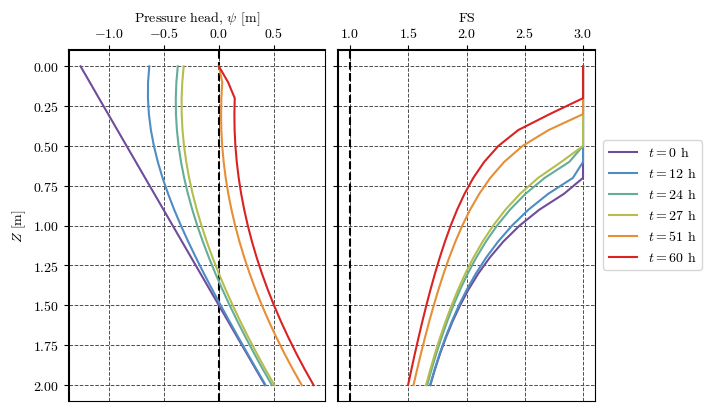

In [29]:
fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(7, 4), sharey=True, layout='constrained')

palette = mpl.colormaps['gnuplot_r']
palette = cmap
for ax in axs:
    ax.grid(True, color='0.3', ls='--', lw=0.7)
    ax.spines["top"].set_linewidth(1.5)
    ax.spines["left"].set_linewidth(1.5)
    ax.xaxis.set_ticks_position('top')
    ax.xaxis.set_tick_params(top=True, bottom=False)
    ax.xaxis.set_label_position('top')
    ax.set_prop_cycle('color', palette(np.linspace(0, 1, len(output_times))))

axs[0].axvline(0, color='k', lw=1.5, ls='--')
axs[1].axvline(1, color='k', lw=1.5, ls='--')

for n in np.arange(len(output_times)) + 1:
    file = f'{project_name}/outputs/TR_ijz_p_th_{project_name[:8]}_{n}.txt'
    t = read_time(file)
    df = get_df(file)
    df_cell = df[(df['i']==cell[0]) & (df['j']==cell[1])]
    axs[0].plot(df_cell['ψ'], df_cell['z'], label=f'$t={t/3600:.0f}$ h')
    axs[1].plot(df_cell['fs'], df_cell['z'], label=f'$t={t/3600:.0f}$ h')
    axs[0].set(xlabel='Pressure head, $\\psi$ [m]', ylabel='$Z$ [m]')
    axs[1].set(xlabel='FS')
    
axs[1].invert_yaxis()
handles, labels = axs[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='outside right center')
fig.canvas.header_visible = False
fig.canvas.toolbar_position = 'bottom'
plt.show()